In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

import yaml


def save_clustering_score_to_yaml(analysis_output_dir, score):
    data = {'clustering_score': float(score) }
    with open(op.join(analysis_output_dir, 'clustering_score.yaml'), 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

In [2]:
'data/blood/reprocessed/bd-rhap-rep1/bd-rhap-rep1.h5ad'

'data/blood/reprocessed/bd-rhap-rep1/bd-rhap-rep1.h5ad'

In [3]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/bd-rhap-rep1/bd-rhap-rep1.h5ad')
experiment_name = 'bd-rhap-rep1-X'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/netmap/case_studies/blood/{experiment_name}"
# This is where the GRN files are stored.
output_dir_grn = Path(op.join(output_dir, "grn"))
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)


In [4]:
obs['celltype_semi_manual'].unique()

array(['cd14+_monocytes', 'cd14-_monocytes', 'cd4+_tcells', 'nk_cells',
       'DC', 'pDC', 'b_cells', 'cd8+_tcells'], dtype=object)

In [5]:
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"

In [6]:
os.makedirs(analysis_output_dir, exist_ok=True)

In [7]:
grn_adata.obs['celltype_semi_manual'].value_counts()

celltype_semi_manual
cd14+_monocytes    6871
cd14-_monocytes    1352
cd4+_tcells         964
nk_cells            613
DC                  405
cd8+_tcells         347
pDC                 208
b_cells             165
Name: count, dtype: int64

In [8]:
adata_raw.obs['celltype_semi_manual'].value_counts()

celltype_semi_manual
cd14+_monocytes    6871
cd14-_monocytes    1352
cd4+_tcells         964
nk_cells            613
DC                  405
cd8+_tcells         347
pDC                 208
b_cells             165
Name: count, dtype: int64

In [9]:
grn_adata = retrieve_top_edges(grn_adata, output_dir_grn, percentage=0.1 )

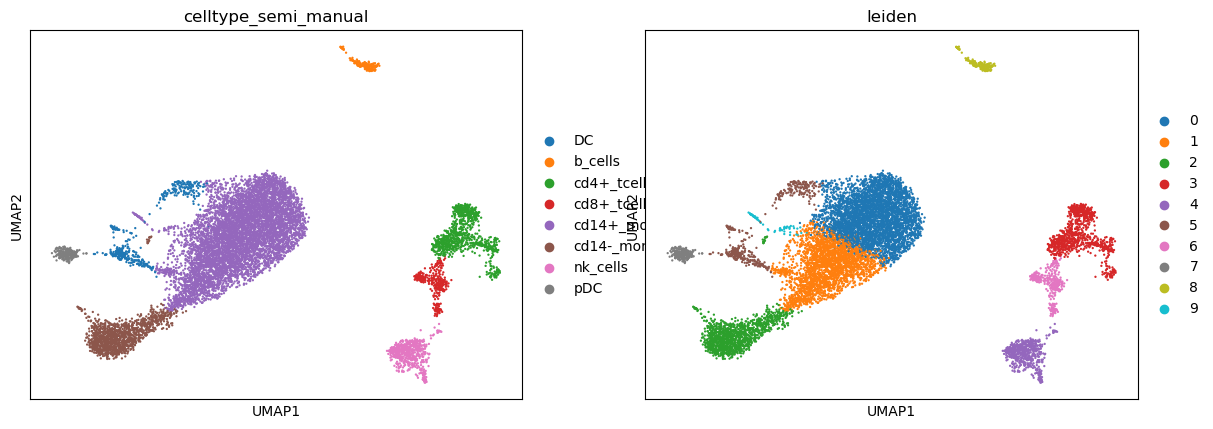

In [10]:
with plt.rc_context(): 
    sc.pl.umap(adata_raw, color = ['celltype_semi_manual', 'leiden'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'gex_clustering_annotation_umap.pdf'), bbox_inches="tight")



In [11]:
grn_adata.var = grn_adata.var.set_index('index')



In [12]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)


In [13]:
sc.tl.tsne(grn_adata)

In [14]:
sc.tl.leiden(grn_adata, resolution=0.29)

In [15]:
with plt.rc_context(): 
    sc.pl.tsne(grn_adata, color = ['leiden', 'celltype_semi_manual'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")

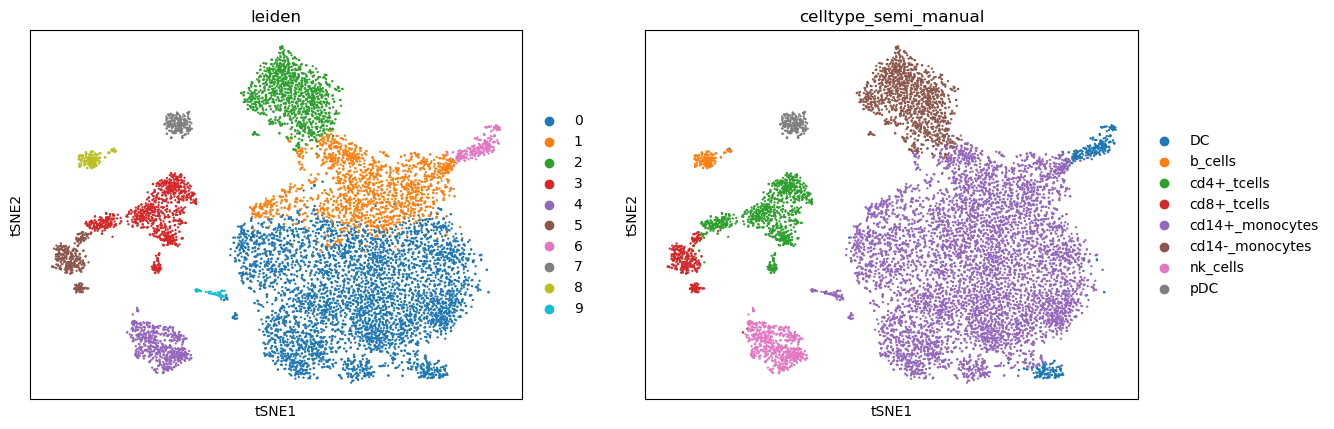

In [16]:
plt.show()

In [17]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import min_weight_full_bipartite_matching
from sklearn.metrics.cluster import contingency_matrix

def unify_group_labelling_max_weight(adata, grn_adata, col_adata, col_grn_adata, return_mapping=True):
    """
    Matches overclustered grn_adata to adata using Maximum Weight Bipartite Matching.
    This ensures every GRN cluster is assigned the 'best' possible reference 
    label while maximizing the global sum of cell overlaps.
    """
    # 1. Compute Contingency Matrix
    # Rows = adata (Ref), Cols = grn_adata (Target)
    cm = contingency_matrix(adata.obs[col_adata], grn_adata.obs[col_grn_adata])
    
    names_ad = np.unique(adata.obs[col_adata])
    names_grn = np.unique(grn_adata.obs[col_grn_adata])
    
    # 2. Maximum Weight Matching
    # SciPy's bipartite matching finds the MINIMUM weight. 
    # To find the MAXIMUM weight, we subtract the matrix from its maximum value.
    # Note: This handles the N > M case (overclustering) by ensuring 
    # each column (GRN cluster) finds its best match in the rows (Ref).
    
    # We transpose because we want a match for every column (GRN cluster)
    # cm.T shape: (n_grn_clusters, n_ref_clusters)
    cost_matrix = cm.max() - cm.T 
    
    # row_ind will correspond to names_grn indices
    # col_ind will correspond to names_ad indices
    # 'min_weight_full_bipartite_matching' will match all nodes of the smaller set.
    # Since we want a mapping for ALL GRN clusters, we use a greedy maximum 
    # weight assignment per cluster.
    
    reverse_mapping = {}
    total_matched_cells = 0
    
    # Efficiently find the max for each GRN cluster
    best_ref_indices = np.argmax(cm, axis=0)
    
    for grn_idx, ref_idx in enumerate(best_ref_indices):
        grn_label = names_grn[grn_idx]
        ref_label = names_ad[ref_idx]
        reverse_mapping[grn_label] = ref_label
        total_matched_cells += cm[ref_idx, grn_idx]

    # 3. Apply Mapping
    col_grn_remapped = f"{col_grn_adata}_remap"
    grn_adata.obs[col_grn_remapped] = grn_adata.obs[col_grn_adata].map(reverse_mapping)
    grn_adata.obs[col_grn_remapped] = pd.Categorical(grn_adata.obs[col_grn_remapped])

    score = total_matched_cells / grn_adata.n_obs
    
    if return_mapping:
        return score, reverse_mapping
    return score

In [18]:
print("\nClustering Score Evaluation")

score, maping = unify_group_labelling_max_weight( adata_raw,grn_adata, 'celltype_semi_manual', 'leiden',True)
print(score)
save_clustering_score_to_yaml(analysis_output_dir, score)


Clustering Score Evaluation
0.974462242562929


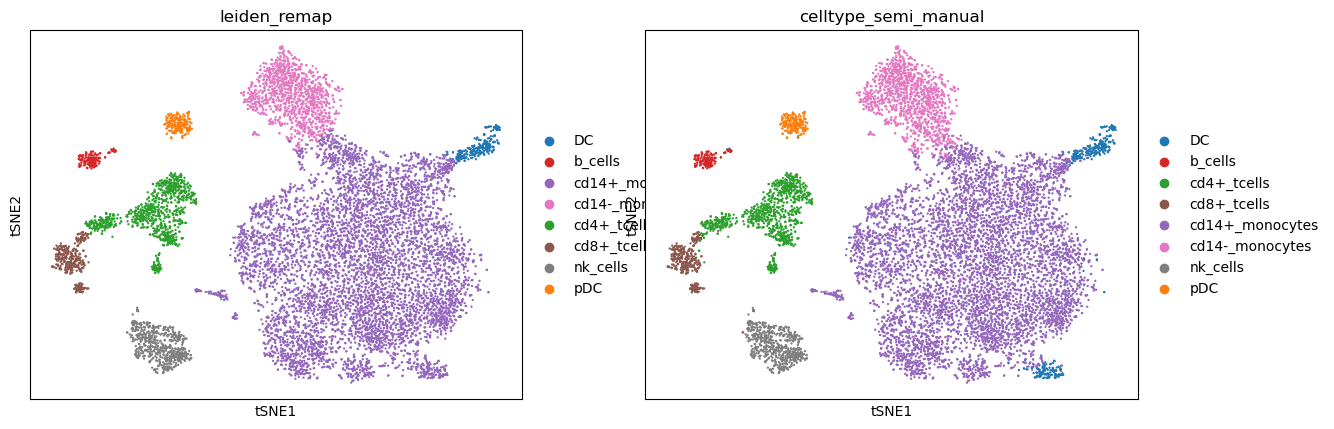

In [58]:


color_mapping  =dict(zip( grn_adata.obs['celltype_semi_manual'].unique(),grn_adata.uns['celltype_semi_manual_colors']))
grn_adata.uns['leiden_remap_colors'] = [color_mapping[x] for x in grn_adata.obs['leiden_remap'].cat.categories]
grn_adata.uns['celltype_semi_manual_colors'] = [color_mapping[x] for x in grn_adata.obs['celltype_semi_manual'].cat.categories]
sc.pl.tsne(grn_adata, color = ['leiden_remap', 'celltype_semi_manual'], color_map='viridis')


In [26]:
grn_adata.obs['celltype_semi_manual'].unique()

['cd14+_monocytes', 'cd14-_monocytes', 'cd4+_tcells', 'nk_cells', 'DC', 'pDC', 'b_cells', 'cd8+_tcells']
Categories (8, object): ['DC', 'b_cells', 'cd4+_tcells', 'cd8+_tcells', 'cd14+_monocytes', 'cd14-_monocytes', 'nk_cells', 'pDC']

In [47]:
grn_adata.obs['leiden_remap'].cat.categories

Index(['DC', 'b_cells', 'cd14+_monocytes', 'cd14-_monocytes', 'cd4+_tcells',
       'cd8+_tcells', 'nk_cells', 'pDC'],
      dtype='object')

In [49]:
grn_adata.uns['leiden_remap_colors'] = [color_mapping[x] for x in grn_adata.obs['leiden_remap'].cat.categories]
grn_adata.uns['celltype_semi_manual_colors'] = [color_mapping[x] for x in grn_adata.obs['celltype_semi_manual'].cat.categories]

In [31]:
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


In [19]:
grn_adata2 = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)
grn_adata2.var = grn_adata2.var.set_index('index')

In [61]:


# To create a new object with 1000 random cells
subset_adata = sc.pp.subsample(adata_raw, n_obs=1000, copy=True)

In [63]:
subset_adata.write_h5ad('/data_nfs/og86asub/blood.h5ad')

In [21]:
add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts' )
grn_adata2 = add_cluster_based_candidate_edges(grn_adata2, threshold=0.5)


In [22]:
index_list = np.where(grn_adata2.var['candidate_edge'])[0]
grn_adata3 = retrieve_edges_by_index(grn_adata2, output_dir_grn, index_list)

In [23]:
grn_adata3.obs = grn_adata2.obs
grn_adata3.obsm['X_pca'] = grn_adata.obsm['X_pca']
grn_adata3.obsm['X_umap'] = grn_adata.obsm['X_umap']

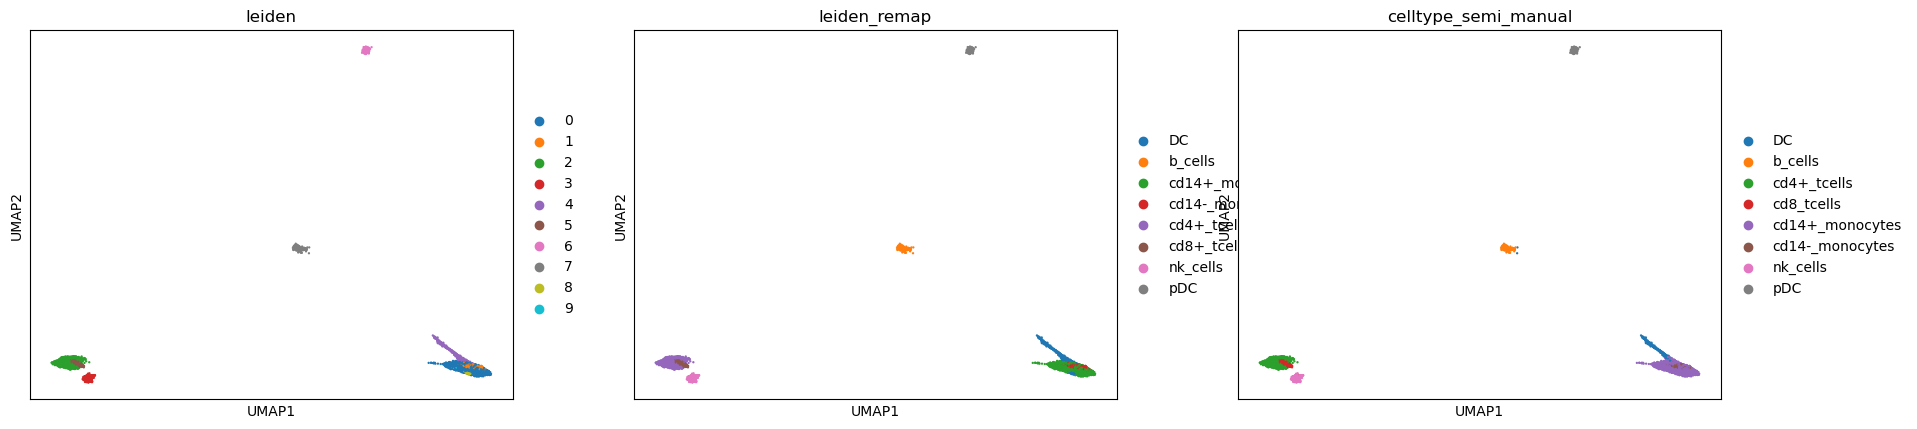

In [24]:
sc.pl.umap(grn_adata3, color = ['leiden', 'leiden_remap', 'celltype_semi_manual'])

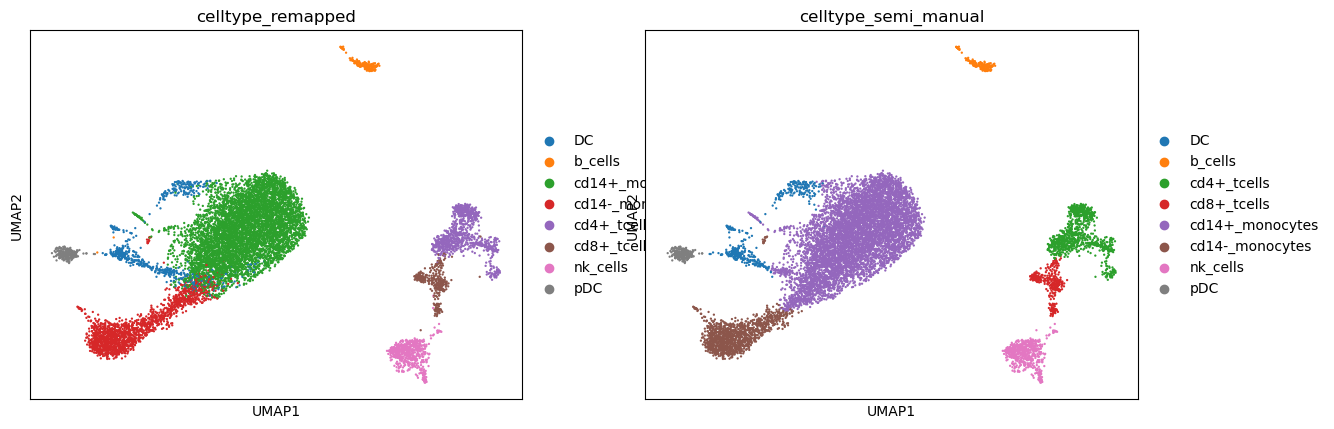

In [25]:
sc.pl.umap(adata_raw, color = ['celltype_remapped', 'celltype_semi_manual' ])

In [26]:
cross_tab = pd.crosstab(grn_adata3.obs['celltype_semi_manual'], grn_adata3.obs['leiden_remap'])

In [27]:
grn_adata3 = add_external_grn(grn_ad=grn_adata3,external_grn=collectri,name_grn='collectri')

In [28]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size
cluster_column = 'leiden_remap'

min_reg_size = 1
add_neighbourhood_expression_mask(adata_raw, grn_adata3, strict=False, layer = 'counts' )



AnnData object with n_obs × n_vars = 10925 × 251276
    obs: 'Unnamed: 0', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'cd14+_monocytes_nonzero', 'cd14+_monocytes_candidate_edge', 'cd14-_monocytes_nonzero', 'cd14-_monocytes_candidate_edge', 'cd4+_tcells_nonzero', 'cd4+_tcells_candidate_edge', 'nk_cells_nonzero', 'nk_cells_candidate_edge', 'DC_nonzero', 'DC_candidate_edge', 'cd8+_tcells

In [29]:
for tp in [10, 20, 30, 40, 50]:
    keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=tp, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True)
    all_regulons = make_cluster_regulon_dataframe(keep_edges)
    regus = aggregate_edges(keep_edges, grn_adata3, key='unique')
    all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
    all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values

    sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

    bcrank = sc.get.rank_genes_groups_df(all_signatures, group = 'DC', key  = 'wilcoxon')
    bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)

    all_regulons = all_regulons.merge(bcrank, left_on = ['source', 'cluster'], right_on=['gene', 'celltype'])
    all_regulons = all_regulons.to_csv(op.join(analysis_output_dir, f'regulons_{tp}.tsv'), sep = '\t')

Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC
DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC
Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC
DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC
Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets

In [30]:
top_per_source = 30
for tp in [10, 20, 30, 40, 50]:
    keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=tp, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True, tf_column='is_source_collectri')
    all_regulons = make_cluster_regulon_dataframe(keep_edges)
    regus = aggregate_edges(keep_edges, grn_adata3, key='unique')
    all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
    all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values

    sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

    bcrank = sc.get.rank_genes_groups_df(all_signatures, group = 'DC', key  = 'wilcoxon')
    bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)

    all_regulons = all_regulons.merge(bcrank, left_on = ['source', 'cluster'], right_on=['gene', 'celltype'])

    
    all_regulons.to_csv(op.join(analysis_output_dir, f'regulons_{tp}_TF.tsv'), sep = '\t')

Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC
DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC
Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC
DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC
Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets

In [31]:
grn_adata3.obs['leiden_remap']

0        cd14+_monocytes
1        cd14-_monocytes
2        cd14+_monocytes
3        cd14-_monocytes
4            cd4+_tcells
              ...       
10920    cd14+_monocytes
10921        cd4+_tcells
10922    cd14+_monocytes
10923    cd14-_monocytes
10924    cd14+_monocytes
Name: leiden_remap, Length: 10925, dtype: category
Categories (8, object): ['DC', 'b_cells', 'cd14+_monocytes', 'cd14-_monocytes', 'cd4+_tcells', 'cd8+_tcells', 'nk_cells', 'pDC']

In [32]:
bcrank

,names,scores,logfoldchanges,pvals,pvals_adj,celltype,gene
0,DC_MAX,26.351027,NaN,4.995361e-153,1.493613e-150,DC,MAX
1,pDC_MAX,24.978039,NaN,1.059273e-137,1.583613e-135,pDC,MAX
2,DC_JUN,24.258043,NaN,5.438508e-130,5.420380e-128,DC,JUN
3,pDC_HMGB2,22.744497,NaN,1.626765e-114,9.728052e-113,pDC,HMGB2
4,DC_TLE5,22.527298,NaN,2.242238e-112,9.577557e-111,DC,TLE5
...,...,...,...,...,...,...,...
294,cd14-_monocytes_LMO4,-21.130806,NaN,4.144102e-99,8.850617e-98,cd14-_monocytes,LMO4
295,cd14-_monocytes_IRF8,-21.532600,NaN,7.708467e-103,1.920693e-101,cd14-_monocytes,IRF8
296,nk_cells_LMO4,-21.614559,3.066002,1.310498e-103,3.562171e-102,nk_cells,LMO4
297,cd8+_tcells_ZNF91,-22.695255,NaN,4.990365e-114,2.486865e-112,cd8+_tcells,ZNF91


In [33]:
# grn_adata3.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
# all_signatures.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

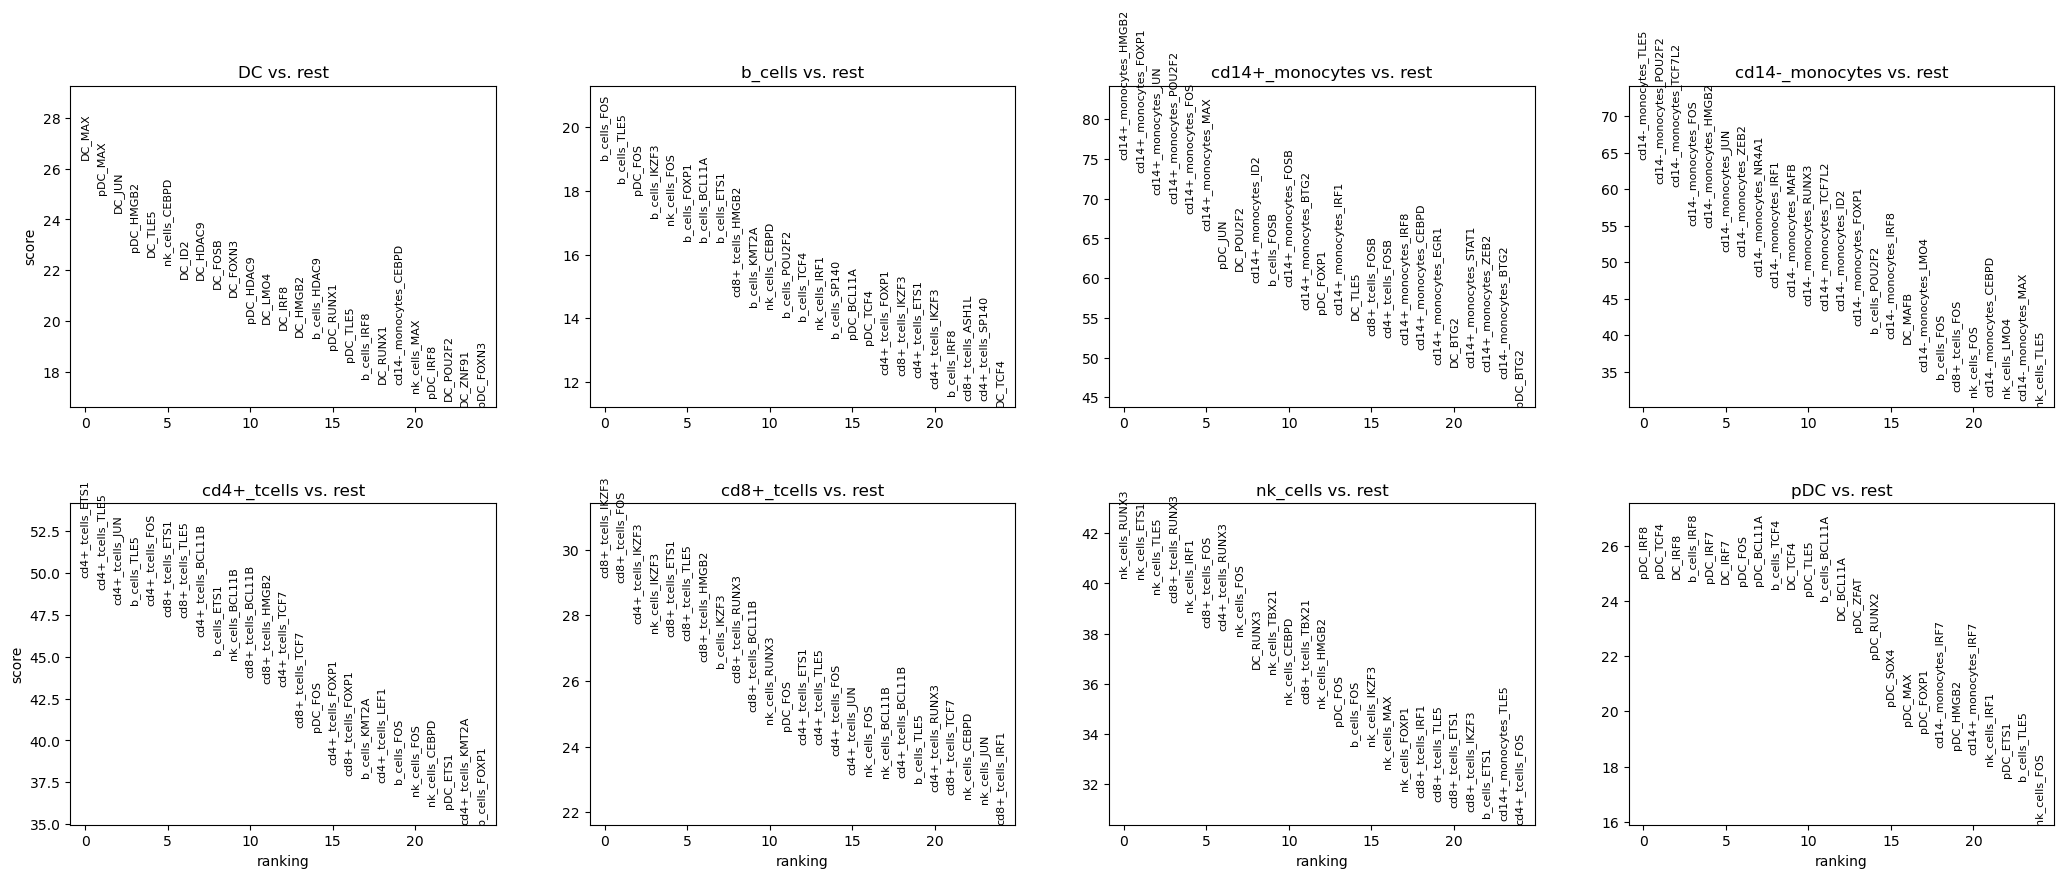

In [34]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(all_signatures, n_genes=25, sharey=False, key="wilcoxon")

In [35]:
pp = rank_regulon_groups_dotplot(grn_adata3, adata_regl=all_signatures, return_fig=True, new_cluster_column=cluster_column, n_genes=10)

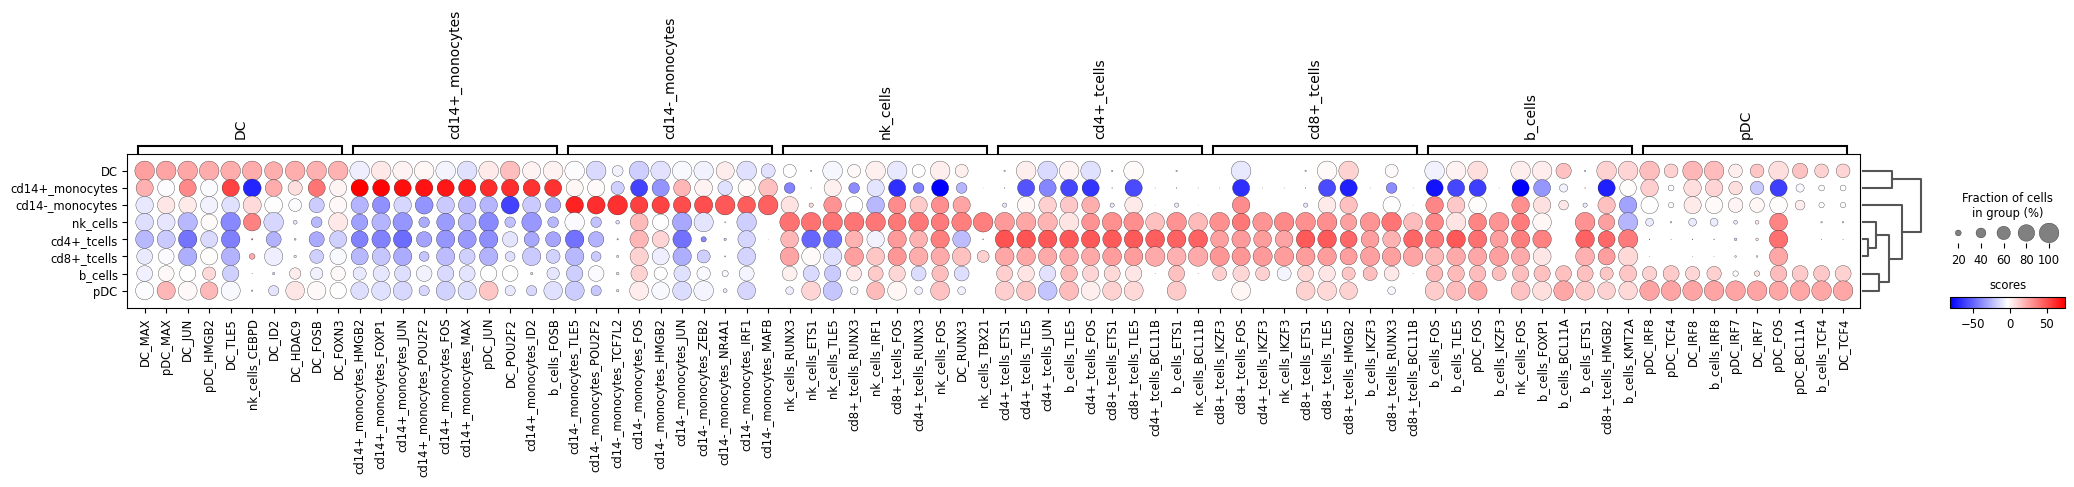

In [36]:
pp.show()

In [37]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(adata_raw, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(adata_raw, n_genes=25, sharey=False, key="wilcoxon")

KeyError: 'leiden_remap'

In [ ]:

bcrank = sc.get.rank_genes_groups_df(all_signatures, group = 'DC', key  = 'wilcoxon')


In [ ]:
all_signatures

AnnData object with n_obs × n_vars = 10925 × 299
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual', 'celltype_remapped', 'leiden_remap'
    uns: 'wilcoxon'
    obsm: 'X_pca', 'X_umap'

In [ ]:
if 'celltype' not in bcrank.columns:
    bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)


In [ ]:
bcrank

,names,scores,logfoldchanges,pvals,pvals_adj,celltype,gene
0,DC_MAX,26.351027,NaN,4.995361e-153,1.493613e-150,DC,MAX
1,pDC_MAX,24.978039,NaN,1.059273e-137,1.583613e-135,pDC,MAX
2,DC_JUN,24.258043,NaN,5.438508e-130,5.420380e-128,DC,JUN
3,pDC_HMGB2,22.744497,NaN,1.626765e-114,9.728052e-113,pDC,HMGB2
4,DC_TLE5,22.527298,NaN,2.242238e-112,9.577557e-111,DC,TLE5
...,...,...,...,...,...,...,...
294,cd14-_monocytes_LMO4,-21.130806,NaN,4.144102e-99,8.850617e-98,cd14-_monocytes,LMO4
295,cd14-_monocytes_IRF8,-21.532600,NaN,7.708467e-103,1.920693e-101,cd14-_monocytes,IRF8
296,nk_cells_LMO4,-21.614552,3.066002,1.310686e-103,3.562684e-102,nk_cells,LMO4
297,cd8+_tcells_ZNF91,-22.695255,NaN,4.990365e-114,2.486865e-112,cd8+_tcells,ZNF91


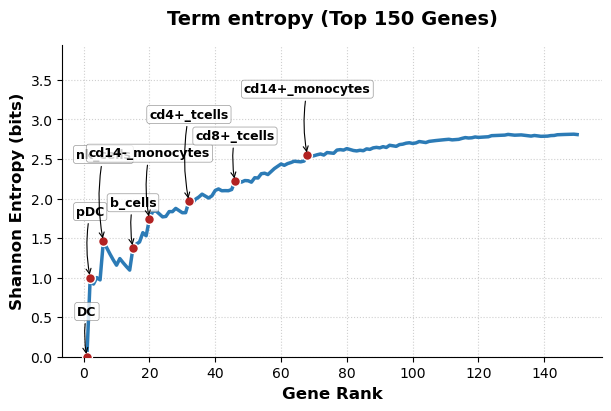

In [ ]:
bcrank_entropy(bcrank, top_n=150, title="Term entropy", figsize=(6,4))